# ***Lab 04. Morphological filtering***

1. Dùng camera chụp ảnh nền gạch, có gạch nứt/vỡ

2. Dùng phuơng phap binarize theo gobal threshold để phan đoạn ảnh -> Anh J2

3. Dung dilation and eoion ap dung hco anh J2 voi kích thuoc cua so neighborhood la 5x5., 2 ảnh rieng

4. Sử dụng các bộ lọc dựa trên kết hợp dilation và erosion để điều chỉnh sao cho thấy rõ các vết nứt/vỡ trên gạch nhất.

5. Sử dụng các bộ lọc kết hợp dilation và erosion để điều chỉnh sao cho ko còn thấy vết nứt vỡ (ảnh J5)

6. Đếm số lượng ô gạch xuất hiện trong ảnh J5

7. Quay lại ảnh gốc. Chuyển về dạng grayscale. Thêm 10% nhiễu salt and pepper. Hãy lọc nhiễu bằng bộ lọc median (cai đặt thủ công, ko dùng co sẵn)

In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_images(panels, figsize=None):
    if figsize is None:
        figsize = (5 * len(panels), 5)

    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    if len(panels) == 1:
        axes = [axes]

    for ax, (subtitle, image) in zip(axes, panels):
        ax.set_title(subtitle)
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()



## 1. Dùng camera chụp ảnh nền gạch, có gạch nứt/vỡ

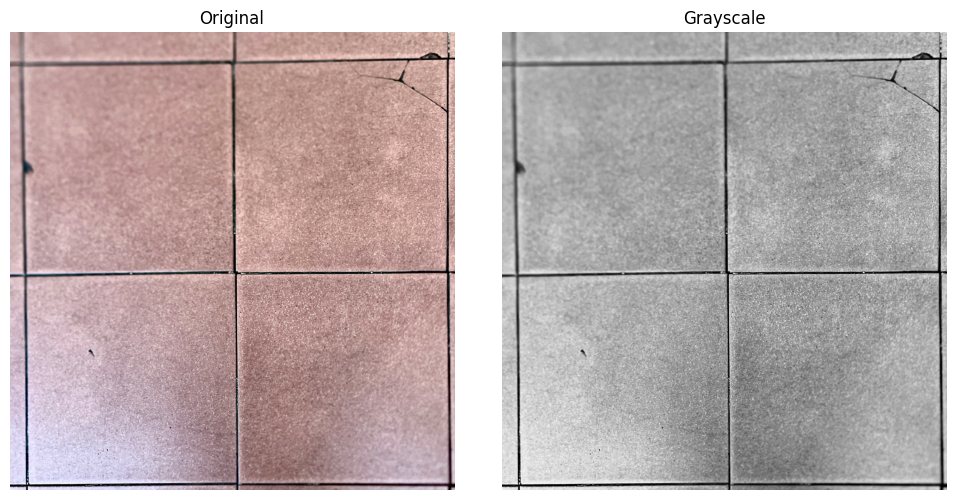

In [4]:
image_path = "image.jpg"
original_bgr = cv2.imread(image_path)
if original_bgr is None:
    raise FileNotFoundError(f"Cannot load {image_path}")

img = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)

show_images([("Original", img), ("Grayscale", gray)])

## 2. Dùng phương pháp binarize theo gobal threshold để phân đoạn ảnh -> Ảnh J2

Global threshold value: 136


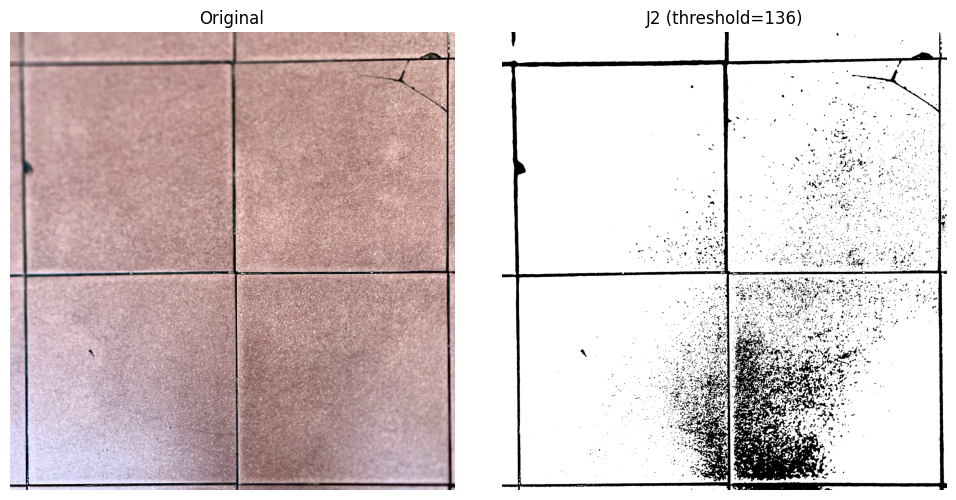

In [5]:
ret, J2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Global threshold value: {ret:.0f}")
show_images(
    [("Original", img), (f"J2 (threshold={ret:.0f})", J2)],
    figsize=(10, 5),
)

## 3. Dùng dilation and éoion áp dụng hco ảnh J2 với kích thước cửa sổ neighborhood là 5x5., 2 ảnh riêng

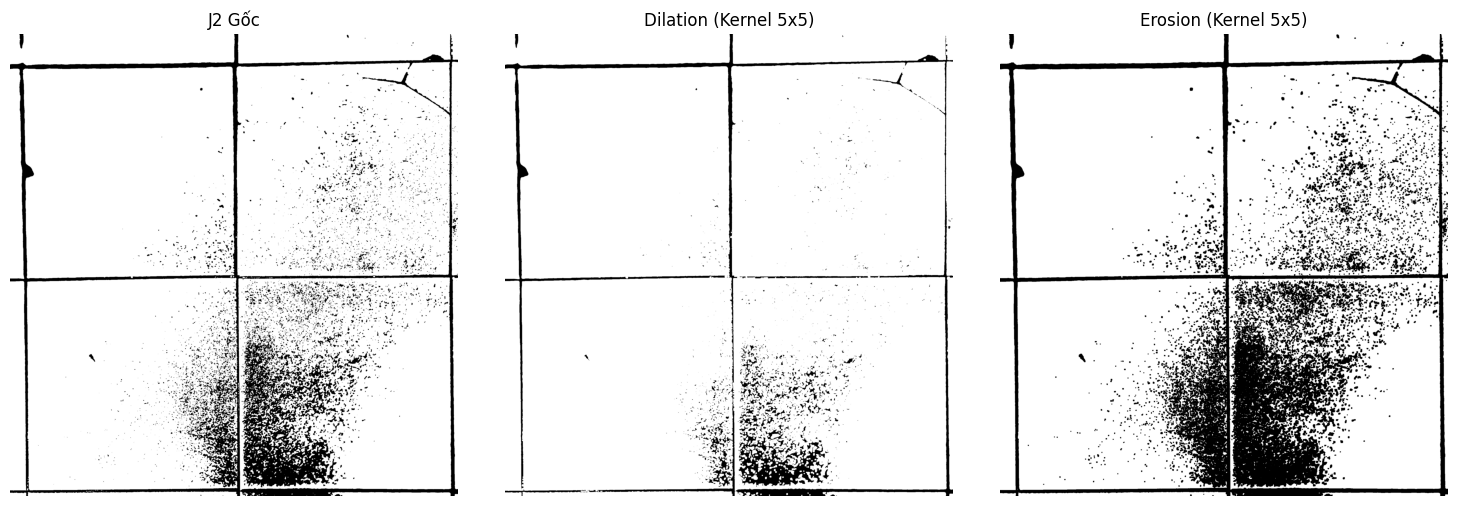

In [6]:
# Tạo kernel 5x5
kernel_5x5 = np.ones((5, 5), np.uint8)

# Dilation: Phình to các vùng trắng (nền gạch), làm thu hẹp/mất đi các vết nứt đen
dilated_J2 = cv2.dilate(J2, kernel_5x5, iterations=1)

# Erosion: Ăn mòn các vùng trắng (nền gạch), làm các vết nứt đen phình to ra
eroded_J2 = cv2.erode(J2, kernel_5x5, iterations=1)

show_images([
    ("J2 Gốc", J2), 
    ("Dilation (Kernel 5x5)", dilated_J2), 
    ("Erosion (Kernel 5x5)", eroded_J2)
], figsize=(15, 5))

## 4. Sử dụng các bộ lọc dựa trên kết hợp dilation và erosion để điều chỉnh sao cho thấy rõ các vết nứt/vỡ trên gạch nhất.

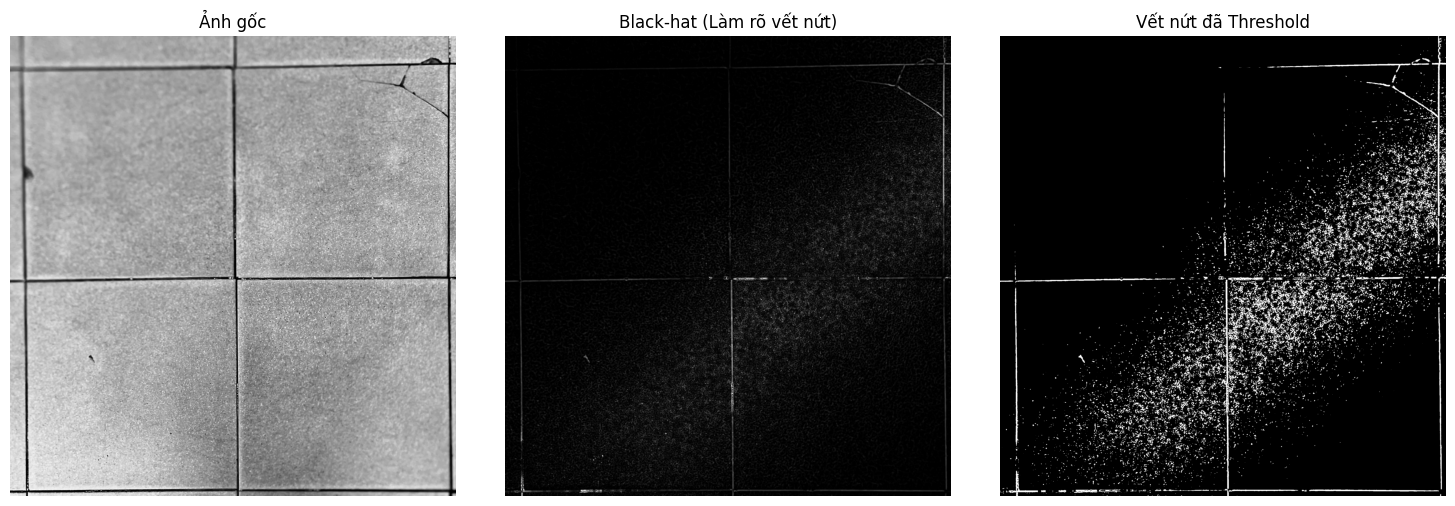

In [7]:
# Để làm nổi bật vết nứt (các rãnh tối trên nền sáng), ta dùng phép toán Black-hat.
# Black-hat = Closing(Ảnh) - Ảnh gốc. Nó trích xuất các chi tiết tối, nhỏ hơn kích thước kernel.
kernel_crack = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))

# Có thể áp dụng trên ảnh xám hoặc ảnh binarize J2. Áp dụng trên ảnh xám thường cho kết quả tự nhiên hơn.
cracks_highlighted = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel_crack)

# Tăng độ tương phản để nhìn rõ vết nứt hơn
_, cracks_thresh = cv2.threshold(cracks_highlighted, 30, 255, cv2.THRESH_BINARY)

show_images([
    ("Ảnh gốc", gray), 
    ("Black-hat (Làm rõ vết nứt)", cracks_highlighted),
    ("Vết nứt đã Threshold", cracks_thresh)
], figsize=(15, 5))

## 5. Sử dụng các bộ lọc kết hợp dilation và erosion để điều chỉnh sao cho ko còn thấy vết nứt vỡ (ảnh J5)

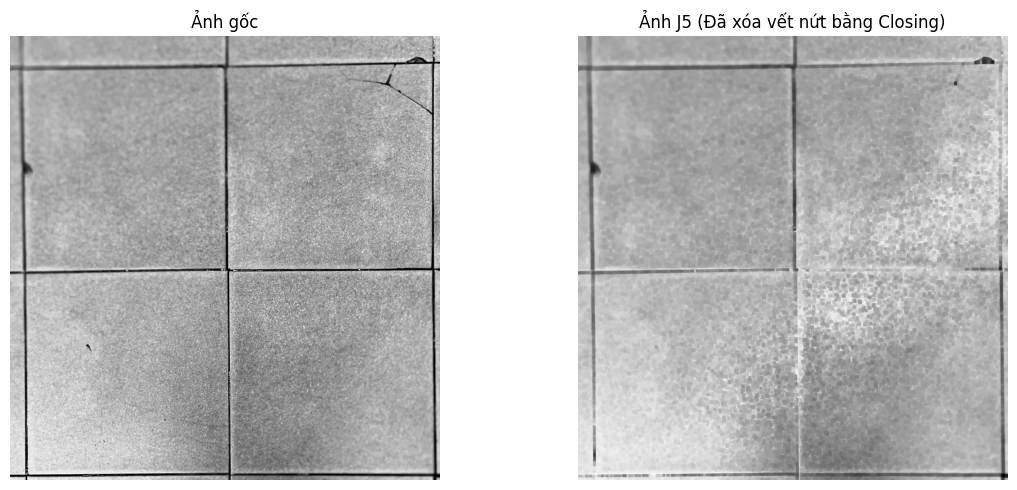

In [8]:
# Phép toán Closing = Dilation sau đó Erosion.
# Nó có tác dụng lấp đầy các lỗ hổng/đốm đen (vết nứt) trên nền trắng (gạch).
kernel_fill = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

# Áp dụng Closing
J5 = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel_fill)

show_images([
    ("Ảnh gốc", gray), 
    ("Ảnh J5 (Đã xóa vết nứt bằng Closing)", J5)
], figsize=(12, 5))

## 6. Đếm số lượng ô gạch xuất hiện trong ảnh J5

In [ ]:
# 1. Tiền xử lý: Làm mờ mạnh để xóa bớt hoa văn (texture) trên mặt gạch
# Giúp thuật toán tìm biên không bị nhầm lẫn bởi các đốm vân gạch
blurred_J5 = cv2.GaussianBlur(J5, (11, 11), 0)

# 2. Tìm biên (Edge Detection) bằng thuật toán Canny
edges = cv2.Canny(blurred_J5, threshold1=30, threshold2=100)

# 3. Solidify (Làm dày và nối liền biên) bằng Dilation và Closing
# Bước này nối các nét đứt gãy của Canny thành một khung lưới khép kín
kernel_solid = np.ones((7, 7), np.uint8)
edges_dilated = cv2.dilate(edges, kernel_solid, iterations=2)
edges_closed = cv2.morphologyEx(edges_dilated, cv2.MORPH_CLOSE, kernel_solid)

# 4. Fill đầy ô gạch: Bằng cách đảo ngược ảnh (Invert)
# Khung viền (đang trắng) -> Đen (0). Lõi gạch (đang đen) -> Trắng (255)
tiles_mask = cv2.bitwise_not(edges_closed)

# 5. Dọn dẹp nhiễu trong lõi gạch: Dùng Opening để xóa các chấm trắng rác vụn
kernel_clean = np.ones((25, 25), np.uint8) # Kernel lớn để dọn sạch rác
tiles_clean = cv2.morphologyEx(tiles_mask, cv2.MORPH_OPEN, kernel_clean)

# 6. Đếm nhãn (Labeling) sử dụng Connected Components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(tiles_clean, connectivity=8)

# Cài đặt ngưỡng diện tích để lọc các vùng trắng không phải là gạch
min_area = 10000 # Tăng ngưỡng lên cao để bỏ qua các góc cạnh thừa
valid_tiles_count = 0
output_count = cv2.cvtColor(J5, cv2.COLOR_GRAY2BGR)

# Duyệt qua các label (Bỏ qua label 0 vì nó là background/khung lưới đen)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    
    # Nếu vùng trắng đủ lớn -> Xác nhận là 1 ô gạch
    if area > min_area:
        valid_tiles_count += 1
        
        # Trích xuất riêng mask của ô gạch này để vẽ viền contour
        single_tile_mask = np.uint8(labels == i) * 255
        contours, _ = cv2.findContours(single_tile_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Vẽ viền xanh lá
        cv2.drawContours(output_count, contours, -1, (0, 255, 0), 3)
        
        # Đánh số thứ tự vào tâm ô gạch
        cX, cY = centroids[i]
        cv2.putText(output_count, f"#{valid_tiles_count}", (int(cX)-20, int(cY)+10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)

print(f"Số lượng ô gạch thực tế đếm được: {valid_tiles_count}")

# Hiển thị các bước để bạn dễ hình dung quá trình
panels_step6 = [
    ("Biên Canny đã Solidify", edges_closed),
    ("Mask Lõi gạch (Đã fill)", tiles_clean),
    ("Kết quả Labeling", output_count)
]
show_images(panels_step6, figsize=(18, 6))

Số lượng ô gạch thực tế đếm được: 5


## 7. Quay lại ảnh gốc. Chuyển về dạng grayscale. Thêm 10% nhiễu salt and pepper. Hãy lọc nhiễu bằng bộ lọc median (cài đặt thủ công, ko dùng có sẵn)

Đang lọc ảnh nhiễu Salt...
Đang lọc ảnh nhiễu Pepper...
Đang lọc ảnh nhiễu Salt & Pepper...
Hoàn tất! Đang hiển thị kết quả...


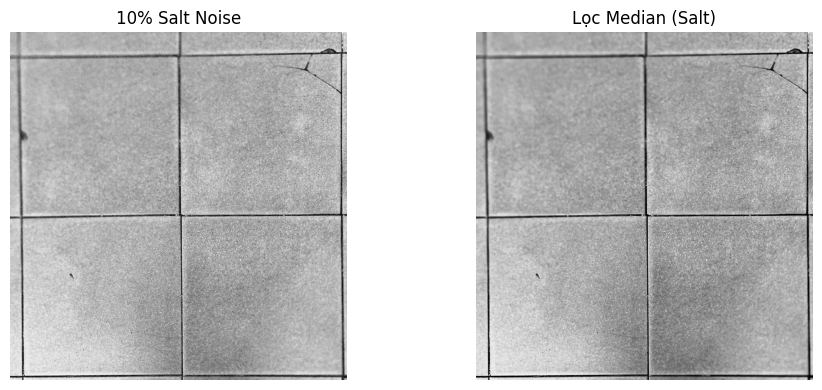

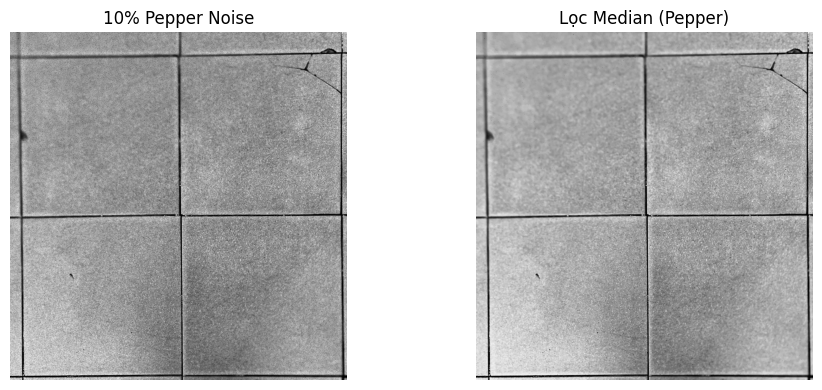

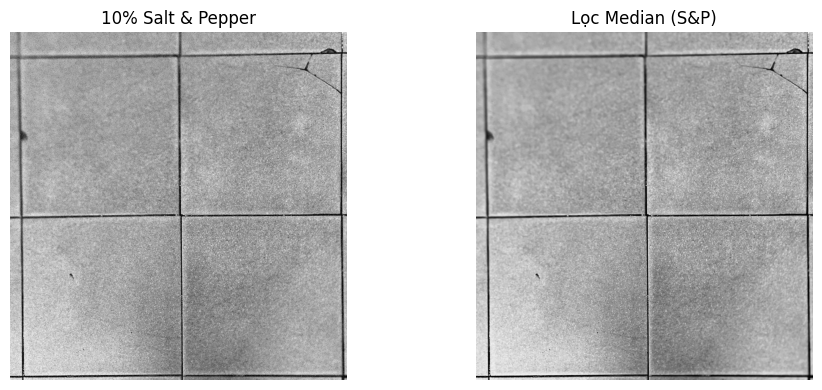

In [11]:
# 1. Khởi tạo các ảnh nhiễu từ ảnh xám gốc
row, col = gray.shape

# --- Ảnh 1: 10% Salt noise (Nhiễu muối - đốm trắng) ---
img_salt = gray.copy()
rand_salt = np.random.rand(row, col)
img_salt[rand_salt < 0.10] = 255

# --- Ảnh 2: 10% Pepper noise (Nhiễu tiêu - đốm đen) ---
img_pepper = gray.copy()
rand_pepper = np.random.rand(row, col)
img_pepper[rand_pepper < 0.10] = 0

# --- Ảnh 3: 10% Salt & Pepper (5% trắng, 5% đen) ---
img_sp = gray.copy()
rand_sp = np.random.rand(row, col)
img_sp[rand_sp < 0.05] = 0                               # 5% Pepper
img_sp[(rand_sp >= 0.05) & (rand_sp < 0.10)] = 255       # 5% Salt

# Cài đặt Median Filter thủ công
def custom_median_filter(image, kernel_size=3):
    # Tạo padding để xử lý các pixel ở viền ảnh
    pad_size = kernel_size // 2
    padded_img = np.pad(image, pad_size, mode='reflect')
    output_img = np.zeros_like(image)
    
    # Duyệt qua từng pixel của ảnh gốc
    for i in range(row):
        for j in range(col):
            # Trích xuất vùng lân cận (window)
            window = padded_img[i : i + kernel_size, j : j + kernel_size]
            # Tính trung vị và gán cho pixel tương ứng
            output_img[i, j] = np.median(window)
            
    return output_img

# 3. Áp dụng bộ lọc cho cả 3 ảnh (Sẽ mất một chút thời gian để chạy xong cả 3)
print("Đang lọc ảnh nhiễu Salt...")
filtered_salt = custom_median_filter(img_salt, kernel_size=3)

print("Đang lọc ảnh nhiễu Pepper...")
filtered_pepper = custom_median_filter(img_pepper, kernel_size=3)

print("Đang lọc ảnh nhiễu Salt & Pepper...")
filtered_sp = custom_median_filter(img_sp, kernel_size=3)

print("Hoàn tất! Đang hiển thị kết quả...")

# 4. Hiển thị kết quả thành 3 nhóm để dễ so sánh
show_images([
    ("10% Salt Noise", img_salt), 
    ("Lọc Median (Salt)", filtered_salt)
], figsize=(10, 4))

show_images([
    ("10% Pepper Noise", img_pepper), 
    ("Lọc Median (Pepper)", filtered_pepper)
], figsize=(10, 4))

show_images([
    ("10% Salt & Pepper", img_sp), 
    ("Lọc Median (S&P)", filtered_sp)
], figsize=(10, 4))